In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

from tqdm import tqdm
tqdm.pandas()

## Data Exploration

In [2]:
def add_market_features(data:pd.DataFrame) -> pd.DataFrame:
    # Feature set 1
    bid_px = data.filter(regex=r"^bid_price[1-5]$")
    bid_vol = data.filter(regex=r"^bid_volume[1-5]$")

    ask_px = data.filter(regex=r"^ask_price[1-5]$")
    ask_vol = data.filter(regex=r"^ask_volume[1-5]$")


    data["spread"] = data["bid_price1"] - data["ask_price1"]
    data["relative_spread"] = (data["bid_price1"] - data["ask_price1"]) / ((data["bid_price1"] + data["ask_price1"])/2)
    data["depth_imbalance_best"] = (data["bid_volume1"] - data["ask_volume1"]) / (data["bid_volume1"] + data["ask_volume1"])

    data["bid_volume_total"] = bid_vol.sum(axis = 1)
    data["ask_volume_total"] = ask_vol.sum(axis = 1)
    data["depth_imbalance_total"] = (data["bid_volume_total"] - data["ask_volume_total"]) / (data["bid_volume_total"] + data["ask_volume_total"])

    data["microprice"] = (data["ask_price1"]*data["bid_volume1"] + data["bid_price1"]*data["ask_volume1"]) / (data["bid_volume1"] + data["ask_volume1"])
    data["microprice_deviation"] = data["microprice"] - data["mid_price"]

    data["vwap_bid"] = (bid_px * bid_vol).sum(axis=1) / data["bid_volume_total"]
    data["vwap_ask"] = (ask_px * ask_vol).sum(axis=1) / data["ask_volume_total"]
    data["vwap_spread"] = data["vwap_bid"] - data["vwap_ask"]

    for k in [1, 5, 10]:
        data[f"mid_price_return_{k}s"] = np.log(data["mid_price"] / data["mid_price"].shift(k))

    for k in [5, 10]:
        data[f"realized_volatility_{k}s"] = (
            data["mid_price_return_1s"].pow(2)
            .rolling(window=k, center=False)
            .mean()
            .apply(np.sqrt)
            )
    data["realized_volatility_10s_shifted"] = data["realized_volatility_10s"].shift(10)
        
    # Feature set 2
    data["order_book_slope_bid"] = (data["bid_price1"] - data["bid_price5"]) / data["bid_volume_total"]
    data["order_book_slope_ask"] = (data["ask_price5"] - data["ask_price1"]) / data["ask_volume_total"]

    data["order_flow_imbalance_l1"] = (
        (data["bid_volume1"].diff() - data["ask_volume1"].diff())
        / (data["bid_volume1"].diff() + data["ask_volume1"].diff()).replace(0, np.nan)
    )

    data["order_flow_imbalance_total"] = (
        (data["bid_volume_total"].diff() - data["ask_volume_total"].diff())
        / (data["bid_volume_total"].diff() + data["ask_volume_total"].diff()).replace(0, np.nan)
    )

    for k in [5, 10]:
        data[f"spread_volatility_{k}s"] = (
            data["spread"]
            .rolling(window=k, min_periods=1)
            .std()
        )

    for k in [5, 10]:
        data[f"return_skew_{k}s"] = (
            data["mid_price_return_1s"]
            .rolling(window=k, min_periods=1)
            .skew()
        )
        data[f"return_kurtosis_{k}s"] = (
            data["mid_price_return_1s"]
            .rolling(window=k, min_periods=1)
            .kurt()
        )

    data["depth_ratio_bid"] = data["bid_volume1"] / (data["bid_volume_total"] + 1e-9)
    data["depth_ratio_ask"] = data["ask_volume1"] / (data["ask_volume_total"] + 1e-9)

    for k in [1, 3, 5, 10]:
        data[f"microprice_return_{k}s"] = np.log(data["microprice"] / data["microprice"].shift(k))
        data[f"ofi_l1_cum_{k}s"] = data["order_flow_imbalance_l1"].rolling(k).sum()
        data[f"ofi_total_cum_{k}s"] = data["order_flow_imbalance_total"].rolling(k).sum()

    for col in ["order_flow_imbalance_l1", "microprice_return_1s"]:
        for k in [5, 10]:
            data[f"{col}_volatility_{k}s"] = data[col].rolling(k).std()
            data[f"{col}_skew_{k}s"] = data[col].rolling(k).skew()
            data[f"{col}_kurtosis_{k}s"] = data[col].rolling(k).kurt()

    data["spread_depth_interaction"] = data["relative_spread"] * data["depth_imbalance_total"]
    data["vol_ofi_interaction"] = data["realized_volatility_5s"] * data["order_flow_imbalance_total"]

    for s in [5, 10, 30]:
        data[f"cost_buy_volume_{s}s"] = ask_vol.sum(axis = 1).rolling(center = False, window=5).sum() * 0.01

    def cost_buy_func(row, s):
        ask_dict = {"ask_volume1":"ask_price1", "ask_volume2":"ask_price2", "ask_volume3":"ask_price3",
                    "ask_volume4":"ask_price4", "ask_volume5":"ask_price5"}
        
        remaining_vol = row[f"cost_buy_volume_{s}s"]
        cost_buy_numerator = 0.0
        cost_buy_denominator = 0.0
        for key, value in ask_dict.items():
            if remaining_vol > 0:
                if (remaining_vol - row[key]) < 0:
                    cost_buy_denominator += remaining_vol
                    cost_buy_numerator += remaining_vol*row[value]
                    remaining_vol = 0
                
                else:
                    cost_buy_denominator += row[key]
                    cost_buy_numerator += row[key]*row[value]
                    remaining_vol-=row[key]
        
        return cost_buy_numerator/cost_buy_denominator if cost_buy_denominator > 0 else 0
    
    for s in [5, 10, 30]:
        data[f"cost_buy_{s}s"] = (data.apply(cost_buy_func, axis = 1, args=(s,)) - data["mid_price"]) / data["mid_price"]




    return data

In [3]:
def data_prep(data:pd.DataFrame, max:int, min:int) -> pd.DataFrame:

    try:
        data["timestamp"] = pd.to_datetime(data["timestamp"], format = "%Y-%m-%d %H:%M:%S")
    except ValueError:
        data["timestamp"] = pd.to_datetime(data["timestamp"], format = "%d-%m-%Y %H:%M")
        data["timestamp"] = data["timestamp"].dt.floor(freq = "min")      # flooring the data to minute resolution

        data["timestamp_second"] = data.groupby("timestamp").cumcount()

        # handling edge case for the first minute - 
        # assumption: head of the missing data is not given, and the tail end is coninuous with the next minute
        row_mask = data["timestamp"] == data["timestamp"].min()
        data.loc[ row_mask, "timestamp_second"] = data.loc[ row_mask, "timestamp_second"] + (60 - data.loc[row_mask, "timestamp"].count())

        data["timestamp"] = data["timestamp"] + pd.to_timedelta(data["timestamp_second"], unit="s")
        data.drop("timestamp_second", axis = 1, inplace = True)


    
    # plot before cleaning
    fig, axes = plt.subplots(1, 2, figsize = (12, 5))
    axes[0].plot(data["timestamp"], data["mid_price"])
    axes[0].set_title("Before Cleaning")
    axes[0].set_xlabel("Dates")
    axes[0].set_ylabel("Mid Price")
    
    # cleaning
    row_mask = ~((data["mid_price"] <= max) & (data["mid_price"] >= min))
    column_mask = [x for x in data.columns if x not in ["label", "timestamp"] ]
    data.loc[row_mask, column_mask] = pd.NA
    
    

    print(
      f"Verifying time series data continuity assuming 1 second resolution: {(
          ((data["timestamp"].nunique() == (data["timestamp"].iloc[-1] - data["timestamp"].iloc[0]).total_seconds() + 1)) and
          ((data["timestamp"].nunique() == (data["timestamp"].max() - data["timestamp"].min()).total_seconds() + 1))
          )}"

      f"\nCount of NAN values across the dataset: {data.isna().sum().sum()}"
    )

    column_mask = [x for x in data.columns if x not in ["label", "timestamp"]] # only direct market data, excluding label and timestamp column
    data.loc[:, column_mask] = data.loc[:, column_mask].ffill(axis = 0)

    if "label" in data.columns:
        data["label_missing_dummy"] = data["label"].isna().astype(int) # dummy for missing values on label
        print(
            f"Count of NAN values in market data, NAN values in 'label': {data[column_mask].isna().sum().sum()}, {data["label"].isna().sum()}"
            )
    else:
        print(
            f"Count of NAN values in the market data post cleaning:", data[column_mask].isna().sum().sum()
        )
    

    # plot after cleaning
    axes[1].plot(data["timestamp"], data["mid_price"])
    axes[1].set_title(f"After Cleaning")
    axes[1].set_xlabel("Dates")
    axes[1].set_ylabel("Mid Price")
    
    plt.tight_layout()
    plt.show()

    data = add_market_features(data)

    return data


Verifying time series data continuity assuming 1 second resolution: True
Count of NAN values across the dataset: 769405
Count of NAN values in market data, NAN values in 'label': 0, 25354


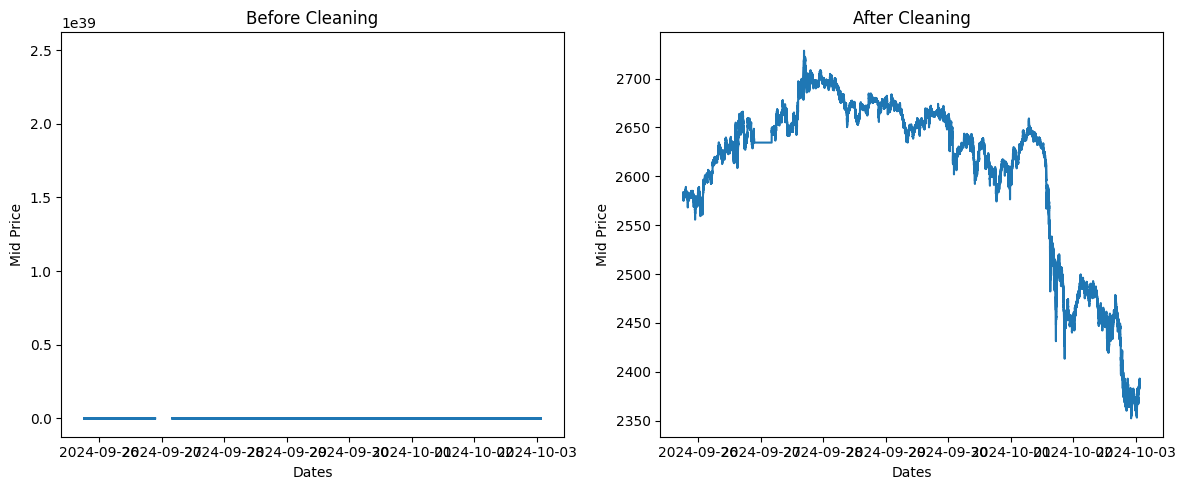

In [4]:
eth = pd.read_csv("../data/train/ETH.csv")
eth = data_prep(eth, 4000, 1000)

Verifying time series data continuity assuming 1 second resolution: True
Count of NAN values across the dataset: 739032
Count of NAN values in the market data post cleaning: 0


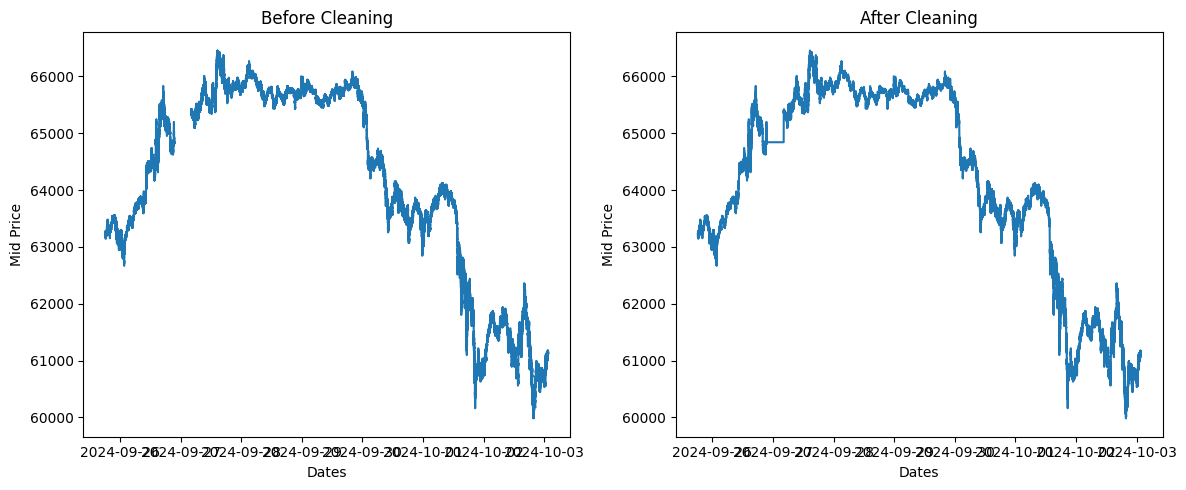

KeyboardInterrupt: 

In [5]:
btc = pd.read_csv("../data/train/BTC.csv")
btc = data_prep(btc, 70000, 40000)

doge = pd.read_csv("../data/train/DOGE.csv")
doge = data_prep(doge, 1, 0)


dot = pd.read_csv("../data/train/DOT.csv")
dot = data_prep(dot, 20, 0)

link = pd.read_csv("../data/train/LINK.csv")
link = data_prep(link, 35, 0)


shib = pd.read_csv("../data/train/SHIB.csv")
shib = data_prep(shib, 1, 0)


sol = pd.read_csv("../data/train/SOL.csv")
sol = data_prep(sol, 300, 60)


In [ ]:
# doge dot link shib sol
aa

NameError: name 'aa' is not defined

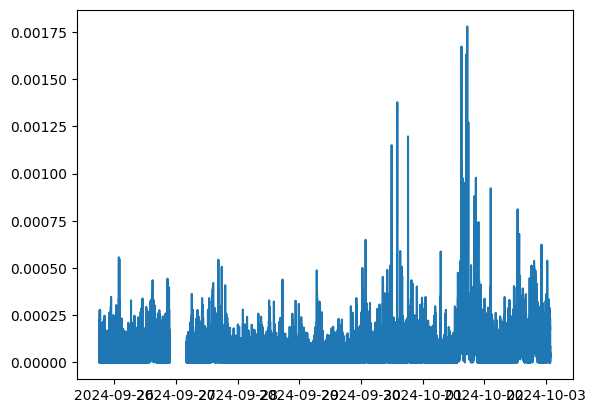

In [ ]:
plt.plot(eth["timestamp"], eth["label"])

In [ ]:
# vol_price_dict = {}
# for df in [doge, btc, dot, link, shib, sol]:
#     vol_price_dict[np.log(df["mid_price"].mean() + 1)] = (df["realized_volatility_5s"].mean(), df["realized_volatility_10s"].mean())

# numerator1 = 0
# numerator2 = 0
# denominator1 = 0
# denominator2 = 0
# for weight, values in vol_price_dict.items():
#     numerator1 += weight*values[0]
#     denominator1 += weight

#     numerator2 += weight*values[1]
#     denominator2 += weight

# market_realised_volatility_5s = numerator1 / denominator1
# market_realised_volatility_10s = numerator2 / denominator2


In [6]:
eth

,timestamp,mid_price,bid_price1,bid_volume1,bid_price2,bid_volume2,bid_price3,bid_volume3,bid_price4,bid_volume4,bid_price5,bid_volume5,ask_price1,ask_volume1,ask_price2,ask_volume2,ask_price3,ask_volume3,ask_price4,ask_volume4,ask_price5,ask_volume5,label,label_missing_dummy,spread,relative_spread,depth_imbalance_best,bid_volume_total,ask_volume_total,depth_imbalance_total,microprice,microprice_deviation,vwap_bid,vwap_ask,vwap_spread,mid_price_return_1s,mid_price_return_5s,mid_price_return_10s,realized_volatility_5s,realized_volatility_10s,realized_volatility_10s_shifted,order_book_slope_bid,order_book_slope_ask,order_flow_imbalance_l1,order_flow_imbalance_total,spread_volatility_5s,spread_volatility_10s,return_skew_5s,return_kurtosis_5s,return_skew_10s,return_kurtosis_10s,depth_ratio_bid,depth_ratio_ask,microprice_return_1s,ofi_l1_cum_1s,ofi_total_cum_1s,microprice_return_3s,ofi_l1_cum_3s,ofi_total_cum_3s,microprice_return_5s,ofi_l1_cum_5s,ofi_total_cum_5s,microprice_return_10s,ofi_l1_cum_10s,ofi_total_cum_10s,order_flow_imbalance_l1_volatility_5s,order_flow_imbalance_l1_skew_5s,order_flow_imbalance_l1_kurtosis_5s,order_flow_imbalance_l1_volatility_10s,order_flow_imbalance_l1_skew_10s,order_flow_imbalance_l1_kurtosis_10s,microprice_return_1s_volatility_5s,microprice_return_1s_skew_5s,microprice_return_1s_kurtosis_5s,microprice_return_1s_volatility_10s,microprice_return_1s_skew_10s,microprice_return_1s_kurtosis_10s,spread_depth_interaction,vol_ofi_interaction,cost_buy_volume_5s,cost_buy_volume_10s,cost_buy_volume_30s,cost_buy_5s,cost_buy_10s,cost_buy_30s
0,2024-09-25 18:13:28,2581.605,2581.60,2980.3,2581.59,44.8,2581.56,139.1,2581.54,86.3,2581.51,110.7,2581.61,339.0,2581.67,9.2,2581.69,0.2,2581.70,23.4,2581.71,1.2,0.000060,0,-0.01,-0.000004,0.795740,3361.2,373.0,0.800225,2581.608979,0.003979,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000027,0.000268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.886677,0.908847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.099719e-06,NaN,NaN,NaN,NaN,0.00,0.00,0.00
1,2024-09-25 18:13:29,2581.285,2581.28,1400.6,2581.22,7.8,2581.19,5.0,2581.18,67.1,2581.17,53.4,2581.29,807.2,2581.30,144.4,2581.31,32.0,2581.32,151.0,2581.33,67.1,0.000057,0,-0.01,-0.000004,0.268774,1533.9,1201.7,0.121436,2581.286344,0.001344,0.0,0.0,0.0,-0.000124,NaN,NaN,NaN,NaN,NaN,0.000072,0.000033,1.842465,2.659724,3.215549e-13,3.215549e-13,NaN,NaN,NaN,NaN,0.913097,0.671715,-1.249821e-04,1.842465,2.659724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.704474e-07,NaN,NaN,NaN,NaN,0.00,0.00,0.00
2,2024-09-25 18:13:30,2581.285,2581.28,875.2,2581.22,7.8,2581.20,64.2,2581.19,5.0,2581.18,5.0,2581.29,807.5,2581.30,144.4,2581.31,32.0,2581.32,151.0,2581.33,52.0,0.000080,0,-0.01,-0.000004,0.040233,957.2,1186.9,-0.107131,2581.285201,0.000201,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,0.000104,0.000034,1.001143,0.949958,2.625484e-13,2.625484e-13,NaN,NaN,NaN,NaN,0.914333,0.680344,-4.426890e-07,1.001143,0.949958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.150305e-07,NaN,NaN,NaN,NaN,0.00,0.00,0.00
3,2024-09-25 18:13:31,2581.105,2581.10,1980.0,2581.09,508.4,2581.08,0.2,2581.05,18.7,2581.03,3.6,2581.11,833.3,2581.15,171.1,2581.20,60.7,2581.29,123.5,2581.30,104.0,0.000087,0,-0.01,-0.000004,0.407600,2510.9,1292.6,0.320310,2581.107038,0.002038,0.0,0.0,0.0,-0.000070,NaN,NaN,NaN,NaN,NaN,0.000028,0.000147,0.954361,0.872605,2.625485e-13,2.625485e-13,0.371761,NaN,0.371761,NaN,0.788562,0.644670,-6.902349e-05,0.954361,0.872605,-1.944483e-04,3.797968,4.482286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.240981e-06,NaN,NaN,NaN,NaN,0.00,0.00,0.00
4,2024-09-25 18:13:32,2581.105,2581.10,1995.5,2581.09,508.4,2581.08,0.2,2581.05,18.7,2581.03,3.6,2581.11,717.3,2581.15,132.0,2581.20,60.7,2581.29,69.2,2581.30,242.9,0.000090,0,-0.01,-0.000004,0.471174,2526.4,1222.1,0.347953,2581.107356,0.002356,0.0,0.0,0.0,0.000000,NaN,NaN,

In [ ]:
columns = ['relative_spread', 'realized_volatility_5s',
           'realized_volatility_10s', 'realized_volatility_10s_shifted']

data = pd.concat([eth, btc[columns].copy().add_prefix("btc_"),
                  dot[columns].copy().add_prefix("dot_"), 
                  link[columns].copy().add_prefix("link_"), 
              #     sol[columns].copy().add_prefix("sol_"), 
              #     shib[columns].copy().add_prefix("shib_"), 
              #     doge[columns].copy().add_prefix("doge_")
                  ], axis = 1)

col_final = columns + [x for x in data.columns if x.startswith(("btc_", "dot_", "link_", "sol_", "shib_", "doge_"))]

In [ ]:
data

,timestamp,mid_price,bid_price1,bid_volume1,bid_price2,bid_volume2,bid_price3,bid_volume3,bid_price4,bid_volume4,bid_price5,bid_volume5,ask_price1,ask_volume1,ask_price2,ask_volume2,ask_price3,ask_volume3,ask_price4,ask_volume4,ask_price5,ask_volume5,label,label_missing_dummy,spread,relative_spread,depth_imbalance_best,bid_volume_total,ask_volume_total,depth_imbalance_total,microprice,microprice_deviation,vwap_bid,vwap_ask,vwap_spread,mid_price_return_1s,mid_price_return_5s,mid_price_return_10s,realized_volatility_5s,realized_volatility_10s,realized_volatility_10s_shifted,order_book_slope_bid,order_book_slope_ask,order_flow_imbalance_l1,order_flow_imbalance_total,IV_t-1s,IV_t-5s,IV_t-1s_delta,IV_RV_ratio_5s,IV_RV_ratio_10s,btc_relative_spread,btc_realized_volatility_5s,btc_realized_volatility_10s,btc_realized_volatility_10s_shifted,dot_relative_spread,dot_realized_volatility_5s,dot_realized_volatility_10s,dot_realized_volatility_10s_shifted,link_relative_spread,link_realized_volatility_5s,link_realized_volatility_10s,link_realized_volatility_10s_shifted
0,2024-09-25 18:13:28,2581.605,2581.60,2980.3,2581.59,44.8,2581.56,139.1,2581.54,86.3,2581.51,110.7,2581.61,339.0,2581.67,9.2,2581.69,0.2,2581.70,23.4,2581.71,1.2,0.000060,0,-0.01,-0.000004,1.0,3361.2,373.0,0.800225,2581.608979,0.003979,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.000027,0.000268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000002,NaN,NaN,NaN,-0.000211,NaN,NaN,NaN,-0.000081,NaN,NaN,NaN
1,2024-09-25 18:13:29,2581.285,2581.28,1400.6,2581.22,7.8,2581.19,5.0,2581.18,67.1,2581.17,53.4,2581.29,807.2,2581.30,144.4,2581.31,32.0,2581.32,151.0,2581.33,67.1,0.000057,0,-0.01,-0.000004,1.0,1533.9,1201.7,0.121436,2581.286344,0.001344,0.0,0.0,0.0,-0.000124,NaN,NaN,NaN,NaN,NaN,0.000072,0.000033,1.842465,2.659724,0.000060,NaN,NaN,NaN,NaN,-0.000002,NaN,NaN,NaN,-0.000211,NaN,NaN,NaN,-0.000081,NaN,NaN,NaN
2,2024-09-25 18:13:30,2581.285,2581.28,875.2,2581.22,7.8,2581.20,64.2,2581.19,5.0,2581.18,5.0,2581.29,807.5,2581.30,144.4,2581.31,32.0,2581.32,151.0,2581.33,52.0,0.000080,0,-0.01,-0.000004,1.0,957.2,1186.9,-0.107131,2581.285201,0.000201,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,0.000104,0.000034,1.001143,0.949958,0.000057,NaN,-3.409909e-06,NaN,NaN,-0.000002,NaN,NaN,NaN,-0.000211,NaN,NaN,NaN,-0.000081,NaN,NaN,NaN
3,2024-09-25 18:13:31,2581.105,2581.10,1980.0,2581.09,508.4,2581.08,0.2,2581.05,18.7,2581.03,3.6,2581.11,833.3,2581.15,171.1,2581.20,60.7,2581.29,123.5,2581.30,104.0,0.000087,0,-0.01,-0.000004,1.0,2510.9,1292.6,0.320310,2581.107038,0.002038,0.0,0.0,0.0,-0.000070,NaN,NaN,NaN,NaN,NaN,0.000028,0.000147,0.954361,0.872605,0.000080,NaN,2.316047e-05,NaN,NaN,-0.000002,NaN,NaN,NaN,-0.000211,NaN,NaN,NaN,-0.000081,NaN,NaN,NaN
4,2024-09-25 18:13:32,2581.105,2581.10,1995.5,2581.09,508.4,2581.08,0.2,2581.05,18.7,2581.03,3.6,2581.11,717.3,2581.15,132.0,2581.20,60.7,2581.29,69.2,2581.30,242.9,0.000090,0,-0.01,-0.000004,1.0,2526.4,1222.1,0.347953,2581.107356,0.002356,0.0,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,0.000028,0.000155,-1.308458,-1.563636,0.000087,NaN,7.140051e-06,NaN,NaN,-0.000002,NaN,NaN,NaN,-0.000211,NaN,NaN,NaN,-0.000081,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631287,2024-10-03 01:34:55,2389.695,2389.69,460.5,2389.68,0.5,2389.66,0.1,2389.65,58.1,2389.60,86.2,2389.70,176.2,2389.71,14.4,2389.72,16.7,2389.76,208.0,2389.80,8.4,0.000057,0,-0.01,-0.000004,1.0,605.4,423.7,0.176562,2389.697233,0.002233,0.0,0.0,0.0,0.000000,0.000000,-0.000004,0.000000,0.000001,0.000060,0.000149,0.000236,-0.689760,1.319218,0.000055,0.000017,3.837819e-05,inf,12.863107,-0.000002,0.000033,0.000023,0.000044,-0.000242,0.0,0.0,0.000153,-0.000093,0.000059,0.000072,0.000029
631288,2024-10-03 01:34:56,2389.615,2389.61,156.9,2389.60,44.4,2389.59,10.0,2389.56,0.5,2389.55,93.7,2389.62,384.7,2389.65,0.2,2389.66,98.6,238

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error
# import numpy as np

# train_clean = eth.replace([np.inf, -np.inf], np.nan).dropna(subset=["label"])

# # Define features and target
# features = [col for col in train_clean.columns if col not in eth.columns[:24].to_list()]
# X = train_clean[features]
# y = train_clean["label"]

# # Split into train and validation sets (75% train, 25% val)
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=False)  # shuffle=False to keep time order

# # Initialize and train model
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

# # Predict on validation set
# y_pred = model.predict(X_val)

# # Calculate RMSE on validation set
# rmse = np.sqrt(mean_squared_error(y_val, y_pred))
# print("Validation RMSE:", rmse)


In [7]:
eth.columns

Index(['timestamp', 'mid_price', 'bid_price1', 'bid_volume1', 'bid_price2',
       'bid_volume2', 'bid_price3', 'bid_volume3', 'bid_price4', 'bid_volume4',
       'bid_price5', 'bid_volume5', 'ask_price1', 'ask_volume1', 'ask_price2',
       'ask_volume2', 'ask_price3', 'ask_volume3', 'ask_price4', 'ask_volume4',
       'ask_price5', 'ask_volume5', 'label', 'label_missing_dummy', 'spread',
       'relative_spread', 'depth_imbalance_best', 'bid_volume_total',
       'ask_volume_total', 'depth_imbalance_total', 'microprice',
       'microprice_deviation', 'vwap_bid', 'vwap_ask', 'vwap_spread',
       'mid_price_return_1s', 'mid_price_return_5s', 'mid_price_return_10s',
       'realized_volatility_5s', 'realized_volatility_10s',
       'realized_volatility_10s_shifted', 'order_book_slope_bid',
       'order_book_slope_ask', 'order_flow_imbalance_l1',
       'order_flow_imbalance_total', 'spread_volatility_5s',
       'spread_volatility_10s', 'return_skew_5s', 'return_kurtosis_5s',
       

In [35]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_clean = eth.copy()
train_clean = train_clean.dropna(subset=["label"])

features =  ['realized_volatility_10s_shifted', 'cost_buy_10s']
# ["realized_volatility_10s", "relative_spread", "mid_price_return_10s", "realized_volatility_5s", "realized_volatility_10s_shifted"]

# [col for col in train_clean.columns if col not in eth.columns[:24].to_list() + eth.columns[44:].to_list()]
                                                              


X = train_clean[features]
y = train_clean["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, shuffle=False, random_state=42
)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': 1,
    'seed': 42
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data]
)

y_pred = model.predict(X_val, num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.6f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 545344, number of used features: 2
[LightGBM] [Info] Start training from score 0.000059
Validation RMSE: 0.000068


In [36]:
mean_label = y_train.mean()
baseline_rmse = np.sqrt(np.mean((y_val - mean_label)**2))
print(f"Baseline RMSE: {baseline_rmse}")


Baseline RMSE: 8.825098107253944e-05


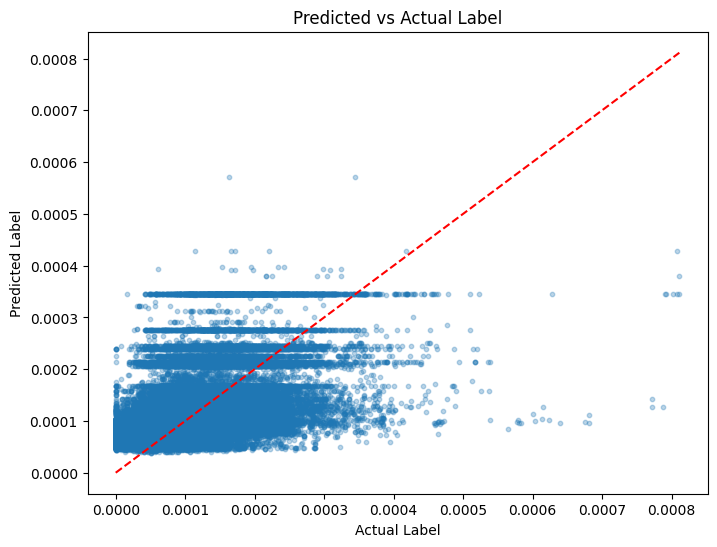

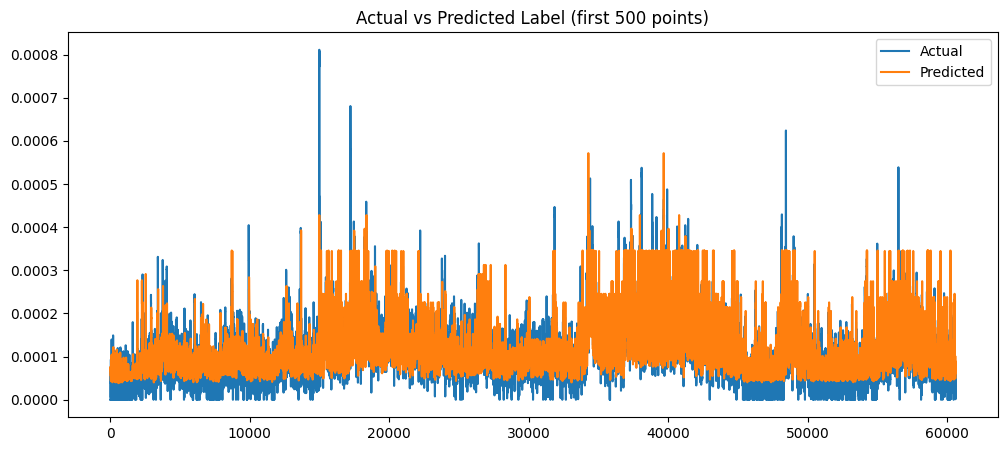

In [37]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.3, s=10)
plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.title("Predicted vs Actual Label")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.show()

# Time series plot (first 500 points)
plt.figure(figsize=(12, 5))
plt.plot(y_val.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Label (first 500 points)")
plt.show()


In [38]:
# If using Booster object:
feature_importances = pd.Series(model.feature_importance(), index=X_train.columns)
top_20 = feature_importances.sort_values(ascending=False).head(20)
print(top_20.index)







Index(['realized_volatility_10s_shifted', 'cost_buy_10s'], dtype='object')


In [39]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(y_val, y_pred)
print(f"Pearson correlation coefficient: {corr:.4f}")
print(f"P-value: {p_value:.4e}")


Pearson correlation coefficient: 0.4499
P-value: 0.0000e+00


In [33]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# === 1. Data split (10% train, 90% test) ===
data = eth.dropna()  # load your data

X_cols = ['realized_volatility_10s_shifted', 'cost_buy_10s']  # replace with your features
y_col = 'label'  # replace with your target col

X = data[X_cols].values.astype(np.float32)
y = data[y_col].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.1, shuffle=False)  # no shuffle for time series

# === 2. Dataset and DataLoader ===
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# === 3. Simple Transformer model for regression ===
class TransformerRegressor(nn.Module):
    def __init__(self, feature_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_linear = nn.Linear(feature_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_linear = nn.Linear(d_model, 1)

    def forward(self, x):
        """
        x: (batch_size, feature_dim)
        Transformer expects (seq_len, batch, feature) -> add dummy seq_len=1 dimension
        """
        x = self.input_linear(x)  # (batch_size, d_model)
        x = x.unsqueeze(0)  # (seq_len=1, batch_size, d_model)
        x = self.transformer_encoder(x)  # (seq_len=1, batch_size, d_model)
        x = x.squeeze(0)  # (batch_size, d_model)
        out = self.output_linear(x)  # (batch_size, 1)
        return out.squeeze(1)  # (batch_size,)

# Instantiate model
model = TransformerRegressor(feature_dim=len(X_cols))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# === 4. Training loop ===
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def train_epoch(model, dataloader):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(dataloader.dataset)

def eval_epoch(model, dataloader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(dataloader.dataset)

# Training
epochs = 10
for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader)
    val_loss = eval_epoch(model, test_loader)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {val_loss:.4f}")


/home/leshleon/projects/goquant_application/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1, Train Loss: 0.0014, Test Loss: 0.0001
Epoch 2, Train Loss: 0.0001, Test Loss: 0.0000
Epoch 3, Train Loss: 0.0000, Test Loss: 0.0001
Epoch 4, Train Loss: 0.0000, Test Loss: 0.0000
Epoch 5, Train Loss: 0.0000, Test Loss: 0.0000
Epoch 6, Train Loss: 0.0000, Test Loss: 0.0000
Epoch 7, Train Loss: 0.0000, Test Loss: 0.0000
Epoch 8, Train Loss: 0.0000, Test Loss: 0.0000
Epoch 9, Train Loss: 0.0000, Test Loss: 0.0000
Epoch 10, Train Loss: 0.0000, Test Loss: 0.0000


In [34]:
import torch
import numpy as np

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)


from scipy.stats import pearsonr

pearson_corr, p_value = pearsonr(all_preds, all_targets)
print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"P-value: {p_value:.4e}")


Pearson correlation coefficient: -0.5616
P-value: 0.0000e+00


In [31]:
print(np.isnan(X_train).any(), np.isinf(X_train).any())
print(np.isnan(y_train).any(), np.isinf(y_train).any())
print(np.isnan(X_test).any(), np.isinf(X_test).any())
print(np.isnan(y_test).any(), np.isinf(y_test).any())


True False
False False
True False
False False
